# Player Visualisations

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mplsoccer import Pitch
from ipywidgets import Dropdown, interact
from IPython.display import display, HTML
import os

from data_reading import get_events, get_player_positions
from shared_visuals import draw_pitch, get_short_name, get_player_nickname
# Global variables
BASE = "https://raw.githubusercontent.com/statsbomb/open-data/master/data"
PITCH_X, PITCH_Y = 120, 80



## Read Data

In [5]:
events_df = get_events(
    target={
    "Competition":"FIFA World Cup",
    "Season": "2022"
    }
    )



c:\Users\luker\OneDrive - University of Bristol\Other\Extra Projects\src\General_visualisations\data_reading.py:274: DtypeWarning: Columns (0: clearance.aerial_won, 1: pass.deflected, 2: block.deflection, 3: foul_committed.advantage, 4: foul_won.advantage, 5: foul_committed.card.name, 6: pass.inswinging, 7: pass.miscommunication, 8: pass.goal_assist, 9: pass.through_ball, 10: shot.one_on_one, 11: dribble.nutmeg, 12: dribble.overrun, 13: 50_50.outcome.name, 14: injury_stoppage.in_chain, 15: dribble.no_touch, 16: clearance.other, 17: pass.outswinging, 18: shot.aerial_won, 19: shot.open_goal, 20: miscontrol.aerial_won, 21: foul_committed.type.name, 22: shot.deflected, 23: pass.cut_back, 24: foul_committed.offensive, 25: block.offensive, 26: shot.saved_to_post, 27: goalkeeper.shot_saved_to_post, 28: foul_committed.penalty, 29: foul_won.penalty, 30: ball_recovery.offensive, 31: pass.straight, 32: pass.no_touch, 33: shot.redirect, 34: goalkeeper.punched_out, 35: bad_behaviour.card.name, 36: 

Event data read from file
Events loaded: (234637, 153)


## Main

In [6]:
def get_player_data(event_data, match_id=None, player_name=None):
    """Return all events for a specific player, optionally filtered to one match."""
    event_data = event_data.copy()

    # Filter for the specific match if match_id is provided
    if match_id is not None:
        event_data = event_data.loc[event_data["match_id"].eq(match_id)].copy()

    # Group events by player_name, then filter for the specific player
    # player_name = event_data["player_name"].dropna().astype(str).unique()[0]
    player_events = event_data.loc[event_data["player_name"].eq(player_name)].copy()
    print("Shape:", player_events.shape)
    return player_events

def get_team_names(event_data):
    """Return a list of unique team names in the event data."""
    return sorted(event_data["team_name"].dropna().astype(str).unique().tolist())

def get_team_players(event_data, team_name):
    """Return a list of unique player names for a specific team that have played in any games."""
    return sorted(event_data.loc[event_data["team_name"] == team_name, "player_name"].dropna().unique().tolist())

def get_matches_by_team(event_data, team_name):
    """Return a list of unique match IDs for a specific team."""
    return sorted(event_data.loc[event_data["team_name"] == team_name, "match_id"].dropna().unique().tolist())

def get_matches_by_player(event_data, player_name):
    """Return a list of unique match IDs for a specific player."""
    return sorted(event_data.loc[event_data["player_name"] == player_name, "match_id"].dropna().unique().tolist())

def get_player_names(event_data):
    """Return a list of unique player names in the event data."""
    return sorted(event_data["player_name"].dropna().astype(str).unique().tolist())

In [7]:
def update_player_dropdown(*args):
    """Update the player dropdown and show the players as a list/table."""
    selected_team = team_dropdown.value
    player_names = get_team_players(events_df, selected_team)

    player_dropdown.options = player_names
    if player_names:
        player_dropdown.value = player_names[0]


def player_display(player_name):
    """Show the player event data in a compact table."""
    player_data = events_df[events_df['player_name'] == player_name]
    display(HTML(player_data.to_html(index=False)))


# Create dropdown choice for available teams
team_names = get_team_names(events_df)
team_dropdown = Dropdown(
    options=team_names,
    description='Select Team:',
    value=team_names[0]
)

player_dropdown = Dropdown(
    options=get_team_players(events_df, team_names[0]),
    description='Select Player:'
)

team_dropdown.observe(update_player_dropdown, names='value')

display(team_dropdown)
display(player_dropdown)

Dropdown(description='Select Team:', options=('Argentina', 'Australia', 'Belgium', 'Brazil', 'Cameroon', 'Cana…

Dropdown(description='Select Player:', options=('Alejandro Darío Gómez', 'Alexis Mac Allister', 'Cristian Gabr…

### Dimensionality Reduction

In [13]:
# Build a player-indexed event structure and a PCA-ready feature matrix

def build_player_event_data(event_data: pd.DataFrame):
    """Return a dict of player -> DataFrame of that player's events."""

    if "player_name" not in event_data.columns:
        event_data["player_name"] = event_data.get("player.name", pd.Series([np.nan] * len(event_data))).fillna("Unknown")

    event_data = event_data.dropna(subset=["player_name"])

    player_data = {
        player_key: player_events.copy()
        for player_key, player_events in event_data.groupby("player_name", sort=True)
    }

    return player_data

if "player_data" not in globals():
    player_data = build_player_event_data(events_df)

if not os.path.exists("player_data.csv"):
    player_df = pd.DataFrame(index=player_data.keys())
    player_df.to_csv("player_data.csv", index=True)
else:
    player_df = pd.read_csv("player_data.csv", index_col=0)

player_feature_matrix = player_df.copy()

player_team_lookup = {}
for player_name, events in player_data.items():
    team_names = events["team_name"].dropna().astype(str)
    if not team_names.empty:
        player_team_lookup[player_name] = team_names.mode().iloc[0]
    else:
        player_team_lookup[player_name] = "Unknown"

player_feature_matrix["team_name"] = [
    player_team_lookup.get(player_name, "Unknown")
    for player_name in player_feature_matrix.index
]

player_feature_matrix["avg_x"] = [events["x"].mean() if "x" in events.columns else np.nan for events in player_data.values()]
player_feature_matrix["avg_y"] = [events["y"].mean() if "y" in events.columns else np.nan for events in player_data.values()]
player_feature_matrix["std_x"] = [events["x"].std() if "x" in events.columns else np.nan for events in player_data.values()]
player_feature_matrix["std_y"] = [events["y"].std() if "y" in events.columns else np.nan for events in player_data.values()]

# Add counts for each event type seen in the competition
for event_type in sorted(events_df["event_type"].dropna().astype(str).unique()):
    player_feature_matrix[event_type] = [
        int((events.get("event_type", pd.Series([np.nan] * len(events))) == event_type).sum())
        for events in player_data.values()
    ]

player_feature_matrix = player_feature_matrix.fillna(0)

# Scale features before dimensionality reduction
scaler = StandardScaler()
player_features_scaled = scaler.fit_transform(player_feature_matrix.drop(columns=["team_name"]))

# Fit PCA on the player feature matrix
pca = PCA(n_components=2)
player_pca = pca.fit_transform(player_features_scaled)

player_pca_df = pd.DataFrame(
    player_pca,
    index=player_feature_matrix.index,
    columns=["PC1", "PC2"],
)
player_pca_df["team_name"] = player_feature_matrix["team_name"].values

team_names = sorted(player_pca_df["team_name"].dropna().astype(str).unique())
palette = sns.color_palette("tab10", n_colors=max(len(team_names), 1))
team_colours = dict(zip(team_names, palette))
teams_to_include = [
    "Japan", "France", "Argentina", "England", 
    "Morocco", "Spain", "Brazil", "Germany", 
    "Ecuador", "Iran", "Ghana", "Costa Rica",
    "Portugal"
]
teams_to_include = team_names
# fig, ax = plt.subplots(figsize=(12, 8))
# for team_name in team_names:
#     if team_name in teams_to_include:
#         team_points = player_pca_df[player_pca_df["team_name"] == team_name]
#         ax.scatter(
#             team_points["PC1"],
#             team_points["PC2"],
#             alpha=0.7,
#             s=10,
#             c=[team_colours[team_name]],
#             label=team_name,
#         )

# players_to_label = ["Lionel Andrés Messi Cuccittini","Harry Kane", "Kylian Mbappé Lottin", "Cristiano Ronaldo"]  
# players_to_label = [name for name in players_to_label if name in player_pca_df.index]

# for player_name in players_to_label:
#     point = player_pca_df.loc[player_name]
#     ax.annotate(
#         player_name,
#         (point["PC1"], point["PC2"]),
#         xytext=(5, 5),
#         textcoords="offset points",
#         fontsize=8,
#         alpha=0.9,
#     )

# ax.set_xlabel("PC1")
# ax.set_ylabel("PC2")
# ax.set_title("PCA of Player Features")
# ax.legend(title="Team", loc="best")
# plt.tight_layout()


### Positions


In [8]:
POSITION_MAP = {
        "Goalkeeper": (5, 40),

        # Defence
        "Right Back": (20, 68),
        "Right Wing Back": (26, 72),
        "Right Center Back": (20, 55),
        "Center Back": (20, 40),
        "Left Center Back": (20, 25),
        "Left Back": (20, 12),
        "Left Wing Back": (26, 8),

        # Defensive midfield
        "Right Defensive Midfield": (42, 52),
        "Center Defensive Midfield": (42, 40),
        "Left Defensive Midfield": (42, 28),

        # Central midfield
        "Right Center Midfield": (58, 60),
        "Center Midfield": (58, 40),
        "Left Center Midfield": (58, 20),

        # Wide midfield
        "Right Midfield": (65, 72),
        "Left Midfield": (65, 8),

        # Attacking midfield
        "Center Attacking Midfield": (72, 40),
        "Left Attacking Midfield": (72, 20),
        "Right Attacking Midfield": (72, 60),

        # Attack
        "Right Wing": (88, 72),
        "Left Wing": (88, 8),

        "Right Center Forward": (92, 60),
        "Left Center Forward": (92, 20),

        "Secondary Striker": (88, 40),
        "Center Forward": (96, 40),
        "Striker": (96, 40),
}

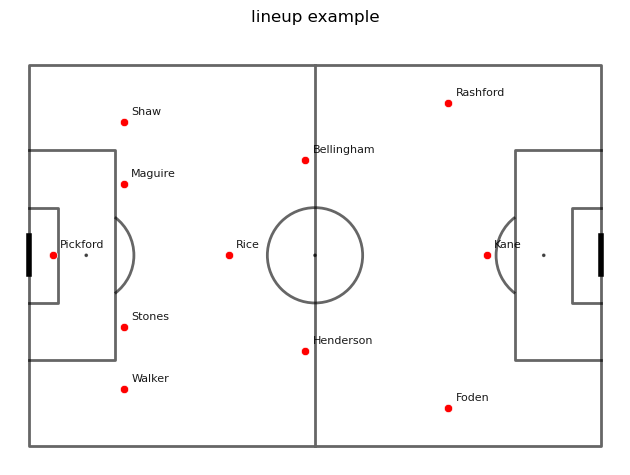

In [32]:
def display_lineup(events_df, season_positions, teamname, title="lineup example", use_nicknames=False):
    '''Visualise the average positions of players on a pitch using mplsoccer.'''
    # Map positions to coordinates
    season_player_coordinates = {}
    for player, pos in season_positions.items():
        x, y = POSITION_MAP[pos]
        season_player_coordinates[player] = [x,y]
    coords = np.array(list(season_player_coordinates.values()))


    # Display on mplsoccer Pitch
    fig, ax = plt.subplots()
    draw_pitch(ax, draw_half=False)
    sns.scatterplot(
        x = coords[:,0],
        y = coords[:,1],
        legend=False,
        c='red',
        )
    fig.suptitle(title, fontsize=12)

    # Get player nickname mappings for the team
    if use_nicknames:
        name_mappings = get_player_nickname(events_df, teamname)
    else:
        name_mappings = {}

    for p in season_player_coordinates.keys():
        name = name_mappings.get(p, get_short_name(p))  # Use the mapping if available, otherwise use the original name
        ax.annotate(
            name,
            POSITION_MAP[season_positions[p]],
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
            alpha=0.9,

            )
    fig.tight_layout()    
    plt.show()

# Get average positions for players over the full competition (EXAMPLE: England)
season_positions = get_player_positions(events_df, "England", season_level=True)
display_lineup(events_df, season_positions, "England", title="lineup example")

### Nickname Mapping

In [33]:
# Get mappings for chosen team
teamname = "Spain"
team_events_df = events_df[events_df["team_name"] == teamname].copy()
spain_mapping_dict = get_player_nickname(events_df, teamname)

# Add to df
team_events_df["player_nickname"] = team_events_df["player_name"].map(spain_mapping_dict)
print(team_events_df[["player_name", "player_nickname"]].drop_duplicates().head(10))


Loading existing mapping from Data_processing\name_mappings\spain_mapping.csv
                      player_name    player_nickname
14717                         NaN                NaN
14720    Pablo Martín Páez Gavira               Gavi
14721        Pau Francisco Torres                NaN
14724   Nicholas Williams Arthuer      Nico Williams
14726     César Azpilicueta Tanco  César Azpilicueta
14727  Rodrigo Hernández Cascante              Rodri
14749        Pedro González López              Pedri
14763    Sergio Busquets i Burgos    Sergio Busquets
14773  Álvaro Borja Morata Martín      Álvaro Morata
14778    Alejandro Balde Martínez    Alejandro Balde


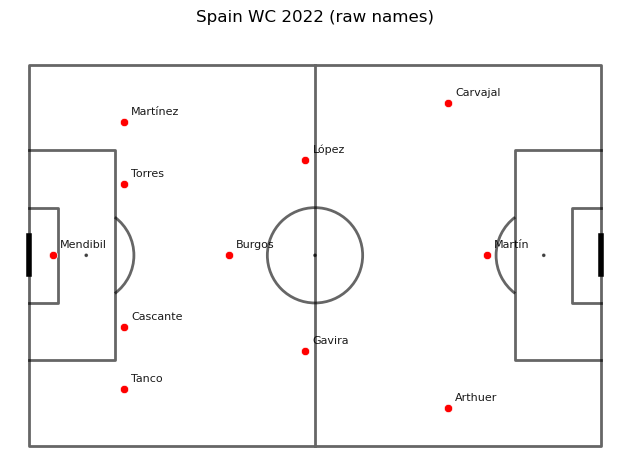

Loading existing mapping from Data_processing\name_mappings\spain_mapping.csv


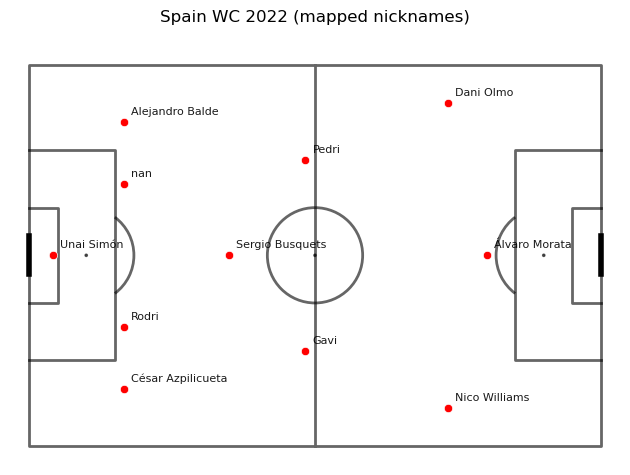

In [34]:
spain_team_positions = get_player_positions(events_df, teamname, season_level=True)
display_lineup(events_df, spain_team_positions, teamname, "Spain WC 2022 (raw names)", use_nicknames=False)
display_lineup(events_df, spain_team_positions, teamname, "Spain WC 2022 (mapped nicknames)", use_nicknames=True)